# xG rolling/difference chart

- Using data from the first 8 rounds of the 2025 J1 League for Yokohama F Marinos.
- Data are from JStats and Sporteria (https://sporteria.jp/data/search_game_images?period_year=2025&game_images_kind_id=19&team_id=124)


## Imports


In [72]:
import urllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from highlight_text import fig_text
from PIL import Image

## Prepare data


In [6]:
# Create a DataFrame to store data
df = pd.DataFrame(
    columns=[
        "Matchday",
        "Date",
        "xG",
        "xGA",
    ]
)

# Add data to the DataFrame
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [1],
                "Date": ["2025-02-15"],
                # Yokohama F. Marinos vs Albirex Niigata
                "xG": [1.21],
                "xGA": [1.24],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [2],
                "Date": ["2025-02-23"],
                # Sanfrecce Hiroshima vs Yokohama F. Marinos
                "xG": [0.81],
                "xGA": [1.28],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [3],
                "Date": ["2025-02-26"],
                # Yokohama F. Marinos vs Yokohama FC
                "xG": [1.2],
                "xGA": [0.75],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [4],
                "Date": ["2025-03-01"],
                # Yokohama F. Marinos vs Shonan Bellmare
                "xG": [0.5],
                "xGA": [0.86],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [5],
                "Date": ["2025-03-16"],
                # Yokohama F. Marinos vs Gamba Osaka
                "xG": [0.72],
                "xGA": [2.13],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [6],
                "Date": ["2025-03-29"],
                # Fagiano Okayama vs Yokohama F. Marinos
                "xG": [0.81],
                "xGA": [1.29],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [7],
                "Date": ["2025-04-02"],
                # Nagoya Grampus vs Yokohama F. Marinos
                "xG": [0.87],
                "xGA": [2.02],
            }
        ),
    ],
    ignore_index=True,
)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "Matchday": [8],
                "Date": ["2025-04-05"],
                # Yokohama F. Marinos vs Tokyo Verdy
                "xG": [0.26],
                "xGA": [0.78],
            }
        ),
    ],
    ignore_index=True,
)

df

C:\Users\daoho\AppData\Local\Temp\ipykernel_6300\2018790345.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


,Matchday,Date,xG,xGA
0,1,2025-02-15,1.21,1.24
1,2,2025-02-23,0.81,1.28
2,3,2025-02-26,1.20,0.75
3,4,2025-03-01,0.50,0.86
4,5,2025-03-16,0.72,2.13
5,6,2025-03-29,0.81,1.29
6,7,2025-04-02,0.87,2.02
7,8,2025-04-05,0.26,0.78


## Calculate the rolling average


In [114]:
# Calculate the rolling mean of xG and xGA
df["xG rolling"] = df["xG"].rolling(window=6).mean()
df["xGA rolling"] = df["xGA"].rolling(window=6).mean()

df

,Matchday,Date,xG,xGA,xG rolling,xGA rolling
0,1,2025-02-15,1.21,1.24,NaN,NaN
1,2,2025-02-23,0.81,1.28,NaN,NaN
2,3,2025-02-26,1.20,0.75,NaN,NaN
3,4,2025-03-01,0.50,0.86,NaN,NaN
4,5,2025-03-16,0.72,2.13,NaN,NaN
5,6,2025-03-29,0.81,1.29,0.875000,1.258333
6,7,2025-04-02,0.87,2.02,0.818333,1.388333
7,8,2025-04-05,0.26,0.78,0.726667,1.305000


## Visualise data


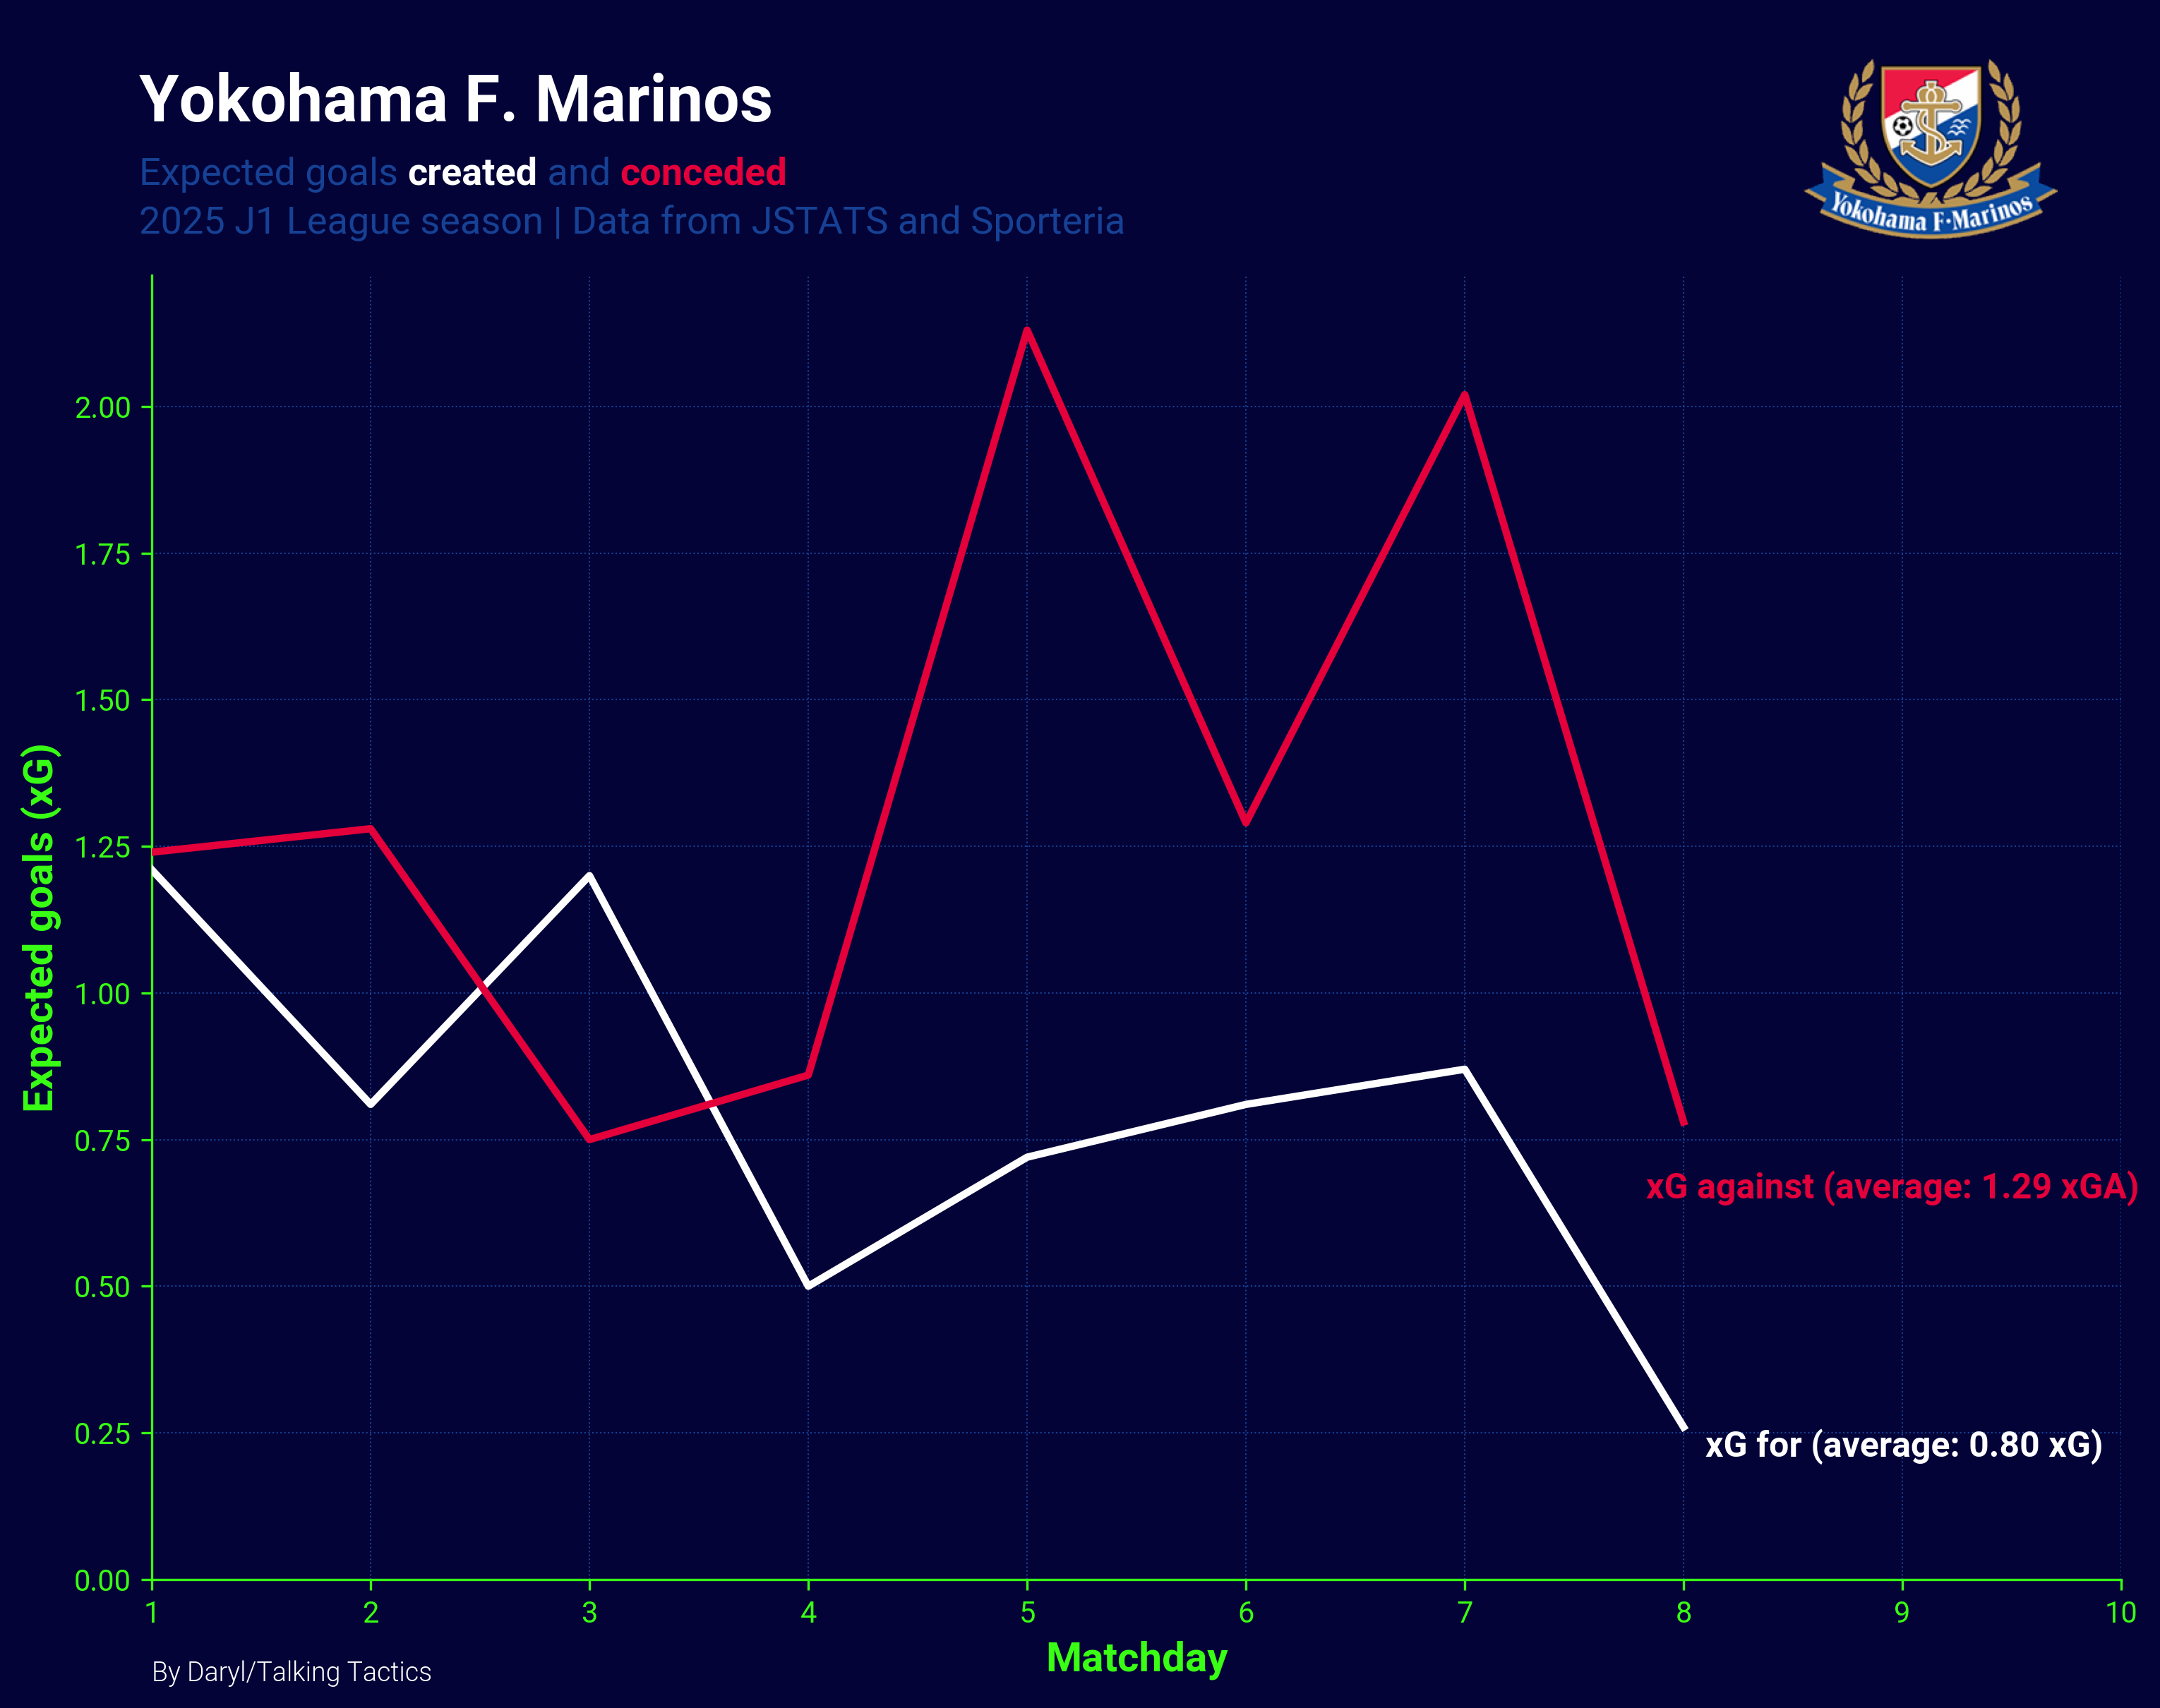

In [118]:
fig = plt.figure(figsize=(12, 8), dpi=300)
ax = plt.subplot(111)

# Remove top and right spines and change the color
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#39FF14")

# Set the grid
ax.grid(visible=True, lw=0.5, ls=":", color="#164194")

# Ensure Matchday is numeric
df["Matchday"] = pd.to_numeric(df["Matchday"], errors="coerce")

# Draw the xG and xGA lines
xG_line = ax.plot(
    df["Matchday"],
    df["xG"],
    color="white",
    lw=2.5,
    label="xG",
    zorder=4,
)
xGA_line = ax.plot(
    df["Matchday"],
    df["xGA"],
    color="#e4003a",
    lw=2.5,
    label="xGA",
    zorder=4,
)

# Change the color of the tick labels
ax.tick_params(axis="x", colors="#39FF14", labelfontfamily="roboto")
ax.tick_params(axis="y", colors="#39FF14", labelfontfamily="roboto")

# Set the x-axis limits
ax.set_xlim(df["Matchday"].min(), df["Matchday"].max() + 2)
# Set the y-axis limits
ax.set_ylim(0)

# Add the axes labels
ax.set_xlabel(
    "Matchday", fontsize=14, color="#39FF14", fontfamily="roboto", fontweight="bold"
)
ax.set_ylabel(
    "Expected goals (xG)",
    fontsize=14,
    color="#39FF14",
    fontfamily="roboto",
    fontweight="bold",
)

# Add text annotations for the lines
ax.text(
    df["Matchday"].max() + 0.1,
    df["xG"].max() - 1,
    f"xG for (average: {df['xG'].mean():.2f} xG)",
    fontsize=12,
    color="white",
    fontfamily="roboto",
    fontweight="bold",
    zorder=3,
)
ax.text(
    df["Matchday"].max() - 0.17,
    df["xGA"].min() - 0.1,
    f"xG against (average: {df['xGA'].mean():.2f} xGA)",
    fontsize=12,
    color="#e4003a",
    fontfamily="roboto",
    fontweight="bold",
    zorder=3,
)

# Add title and subtitle
fig_text(
    x=0.12,
    y=1,
    s="Yokohama F. Marinos",
    fontfamily="roboto",
    color="white",
    weight="bold",
    size=22,
    annotationbbox_kw={"xycoords": "figure fraction"},
)

fig_text(
    x=0.12,
    y=0.95,
    s="Expected goals <created> and <conceded>\n2025 J1 League season | Data from JSTATS and Sporteria",
    highlight_textprops=[
        {"color": xG_line[0].get_color(), "weight": "bold"},
        {"color": xGA_line[0].get_color(), "weight": "bold"},
    ],
    fontfamily="roboto",
    color="#164194",
    size=13,
    annotationbbox_kw={"xycoords": "figure fraction"},
)

# Add footer
fig.text(
    0.125,
    0.05,
    "By Daryl/Talking Tactics",
    fontfamily="roboto",
    fontweight="light",
    fontsize=9,
    color="white",
    ha="left",
)

# Get the logo from Fotmob
fotmob_url = "https://images.fotmob.com/image_resources/logo/teamlogo/"

logo_ax = fig.add_axes([0.75, 0.88, 0.15, 0.15], zorder=1)
club_icon = Image.open(urllib.request.urlopen(f"{fotmob_url}6581.png"))
logo_ax.imshow(club_icon)
logo_ax.axis("off")

# Set the face color of the plot
fig.set_facecolor("#030338")
ax.set_facecolor("#030338")

# Save the figure
plt.savefig(
    "../examples/xg_difference.png", bbox_inches="tight", facecolor=fig.get_facecolor()
)